# 02 — Signal Research

Visualises the momentum signals computed by `src/signals.py`.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src.data import load_prices, compute_returns
from src.signals import load_signals

plt.rcParams.update({'figure.dpi': 120})

PROC = '../data/processed'

prices  = load_prices(PROC)
returns = compute_returns(prices)
sig     = load_signals(PROC)

score   = sig['score']
elig    = sig['eligible']
last    = score.index[-1]

print('Signals loaded:', list(sig.keys()))
print(f'Month-ends: {len(score)}  |  Last: {last.date()}')

Signals loaded: ['dma200', 'eligible', 'mom_12m', 'mom_3m', 'mom_6m', 'score', 'trend', 'vol_60d']
Month-ends: 258  |  Last: 2026-06-30


## 1. Latest month-end snapshot

In [2]:
snapshot = pd.DataFrame({
    'Score':    sig['score'].loc[last],
    '3M %':     sig['mom_3m'].loc[last]  * 100,
    '6M %':     sig['mom_6m'].loc[last]  * 100,
    '12M %':    sig['mom_12m'].loc[last] * 100,
    'Trend %':  sig['trend'].loc[last]   * 100,
    'Vol % pa': sig['vol_60d'].loc[last] * 100,
    'Eligible': sig['eligible'].loc[last].map({True: 'YES', False: 'NO'}),
}).sort_values('Score', ascending=False).round(2)

snapshot

,Score,3M %,6M %,12M %,Trend %,Vol % pa,Eligible
Ticker,,,,,,,
USO,0.40,-4.15,55.86,48.88,14.89,59.59,YES
EEM,0.35,19.69,27.25,45.47,17.38,33.87,YES
IWM,0.30,19.22,18.60,41.10,16.07,20.50,YES
QQQ,0.26,22.38,16.33,33.77,14.06,23.60,YES
SLV,0.23,-18.59,-15.02,62.80,-14.52,54.67,NO
DBC,0.18,-4.70,19.90,26.94,6.23,21.70,YES
SPY,0.16,12.34,8.04,22.63,7.22,14.61,YES
VGK,0.14,9.33,7.91,18.93,6.57,20.60,YES
VNQ,0.11,10.88,11.56,10.77,6.75,15.33,YES


## 2. Score bar chart — eligible vs ineligible

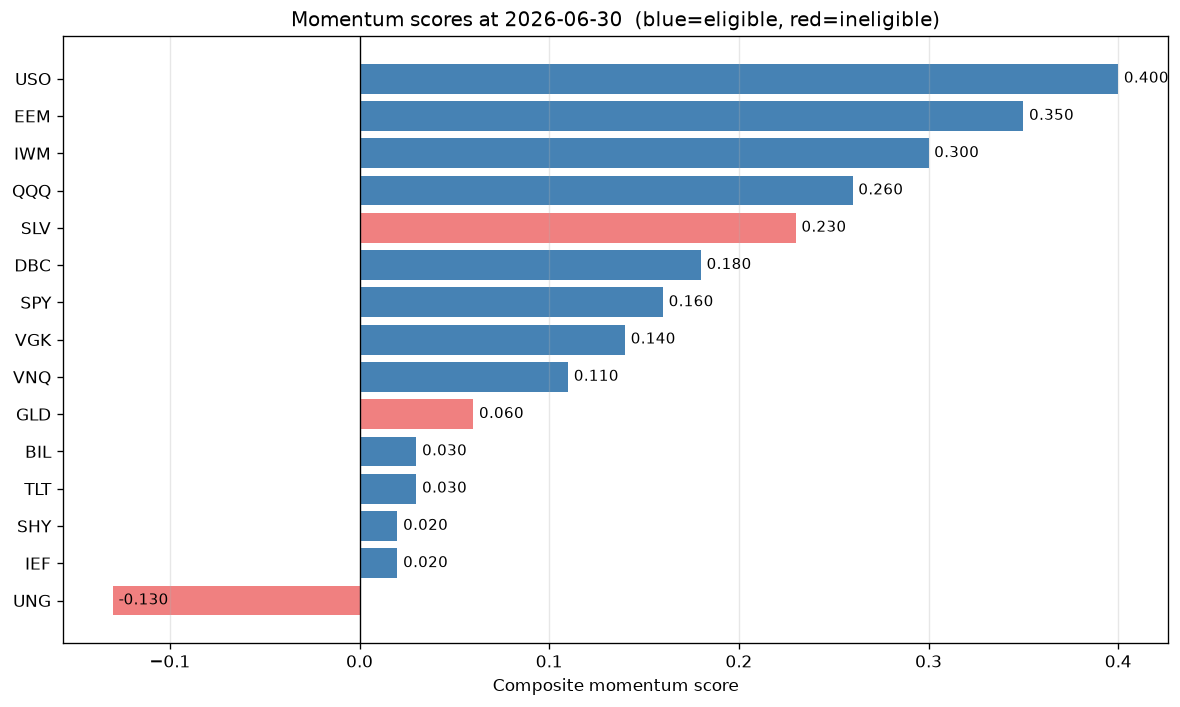

In [3]:
ordered = snapshot.sort_values('Score', ascending=True)
colors  = ['steelblue' if e == 'YES' else 'lightcoral' for e in ordered['Eligible']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ordered.index, ordered['Score'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Composite momentum score')
ax.set_title(f'Momentum scores at {last.date()}  (blue=eligible, red=ineligible)')

for bar, val in zip(bars, ordered['Score']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Score time series — all tickers

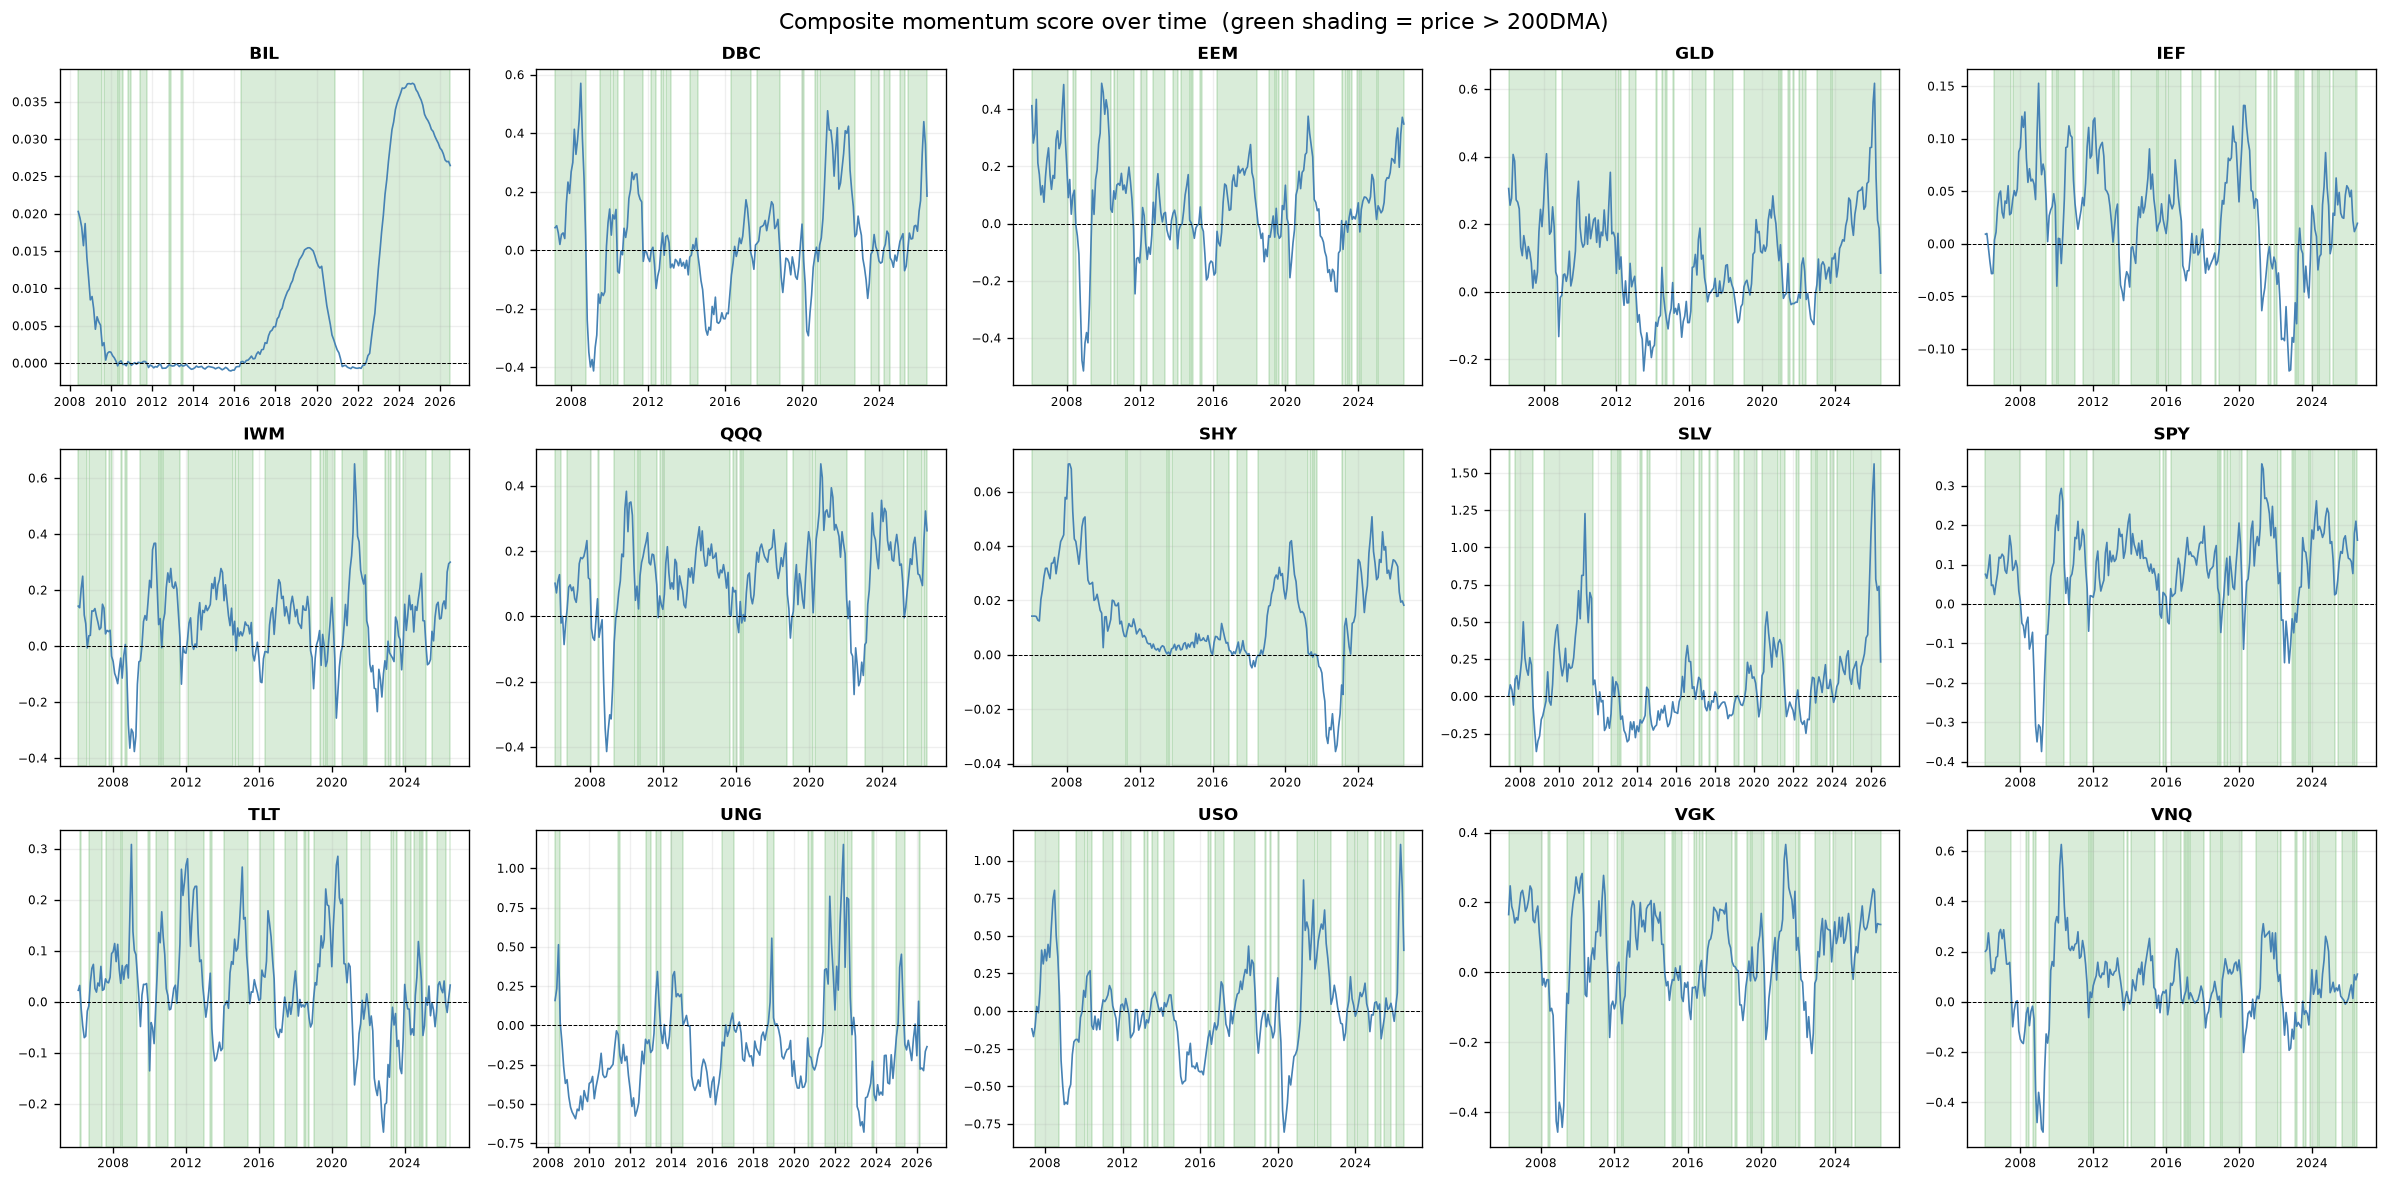

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10), sharey=False)
axes = axes.flatten()

for ax, tkr in zip(axes, score.columns):
    s = score[tkr].dropna()
    e = elig[tkr].reindex(s.index).fillna(False)

    # shade eligible periods green
    in_elig = False
    start   = None
    for dt, el in e.items():
        if el and not in_elig:
            start, in_elig = dt, True
        elif not el and in_elig:
            ax.axvspan(start, dt, alpha=0.15, color='green')
            in_elig = False
    if in_elig:
        ax.axvspan(start, s.index[-1], alpha=0.15, color='green')

    ax.plot(s.index, s.values, linewidth=1, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(tkr, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

# hide unused subplots
for ax in axes[len(score.columns):]:
    ax.set_visible(False)

fig.suptitle('Composite momentum score over time  (green shading = price > 200DMA)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Momentum decomposition — 3M / 6M / 12M at latest date

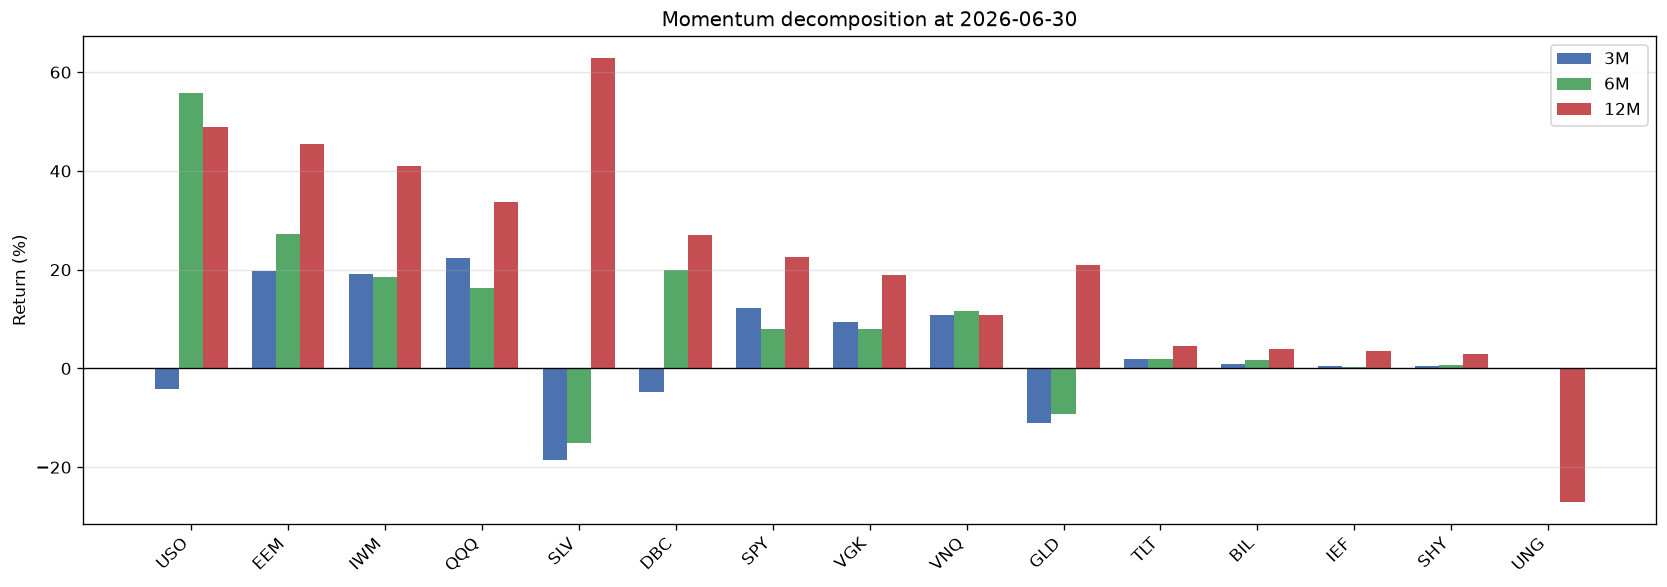

In [5]:
tickers_sorted = snapshot.sort_values('Score', ascending=False).index

x = np.arange(len(tickers_sorted))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w,   sig['mom_3m'].loc[last,  tickers_sorted] * 100, w, label='3M',  color='#4C72B0')
ax.bar(x,       sig['mom_6m'].loc[last,  tickers_sorted] * 100, w, label='6M',  color='#55A868')
ax.bar(x + w,   sig['mom_12m'].loc[last, tickers_sorted] * 100, w, label='12M', color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(tickers_sorted, rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Return (%)')
ax.set_title(f'Momentum decomposition at {last.date()}')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Price vs 200DMA — eligibility check

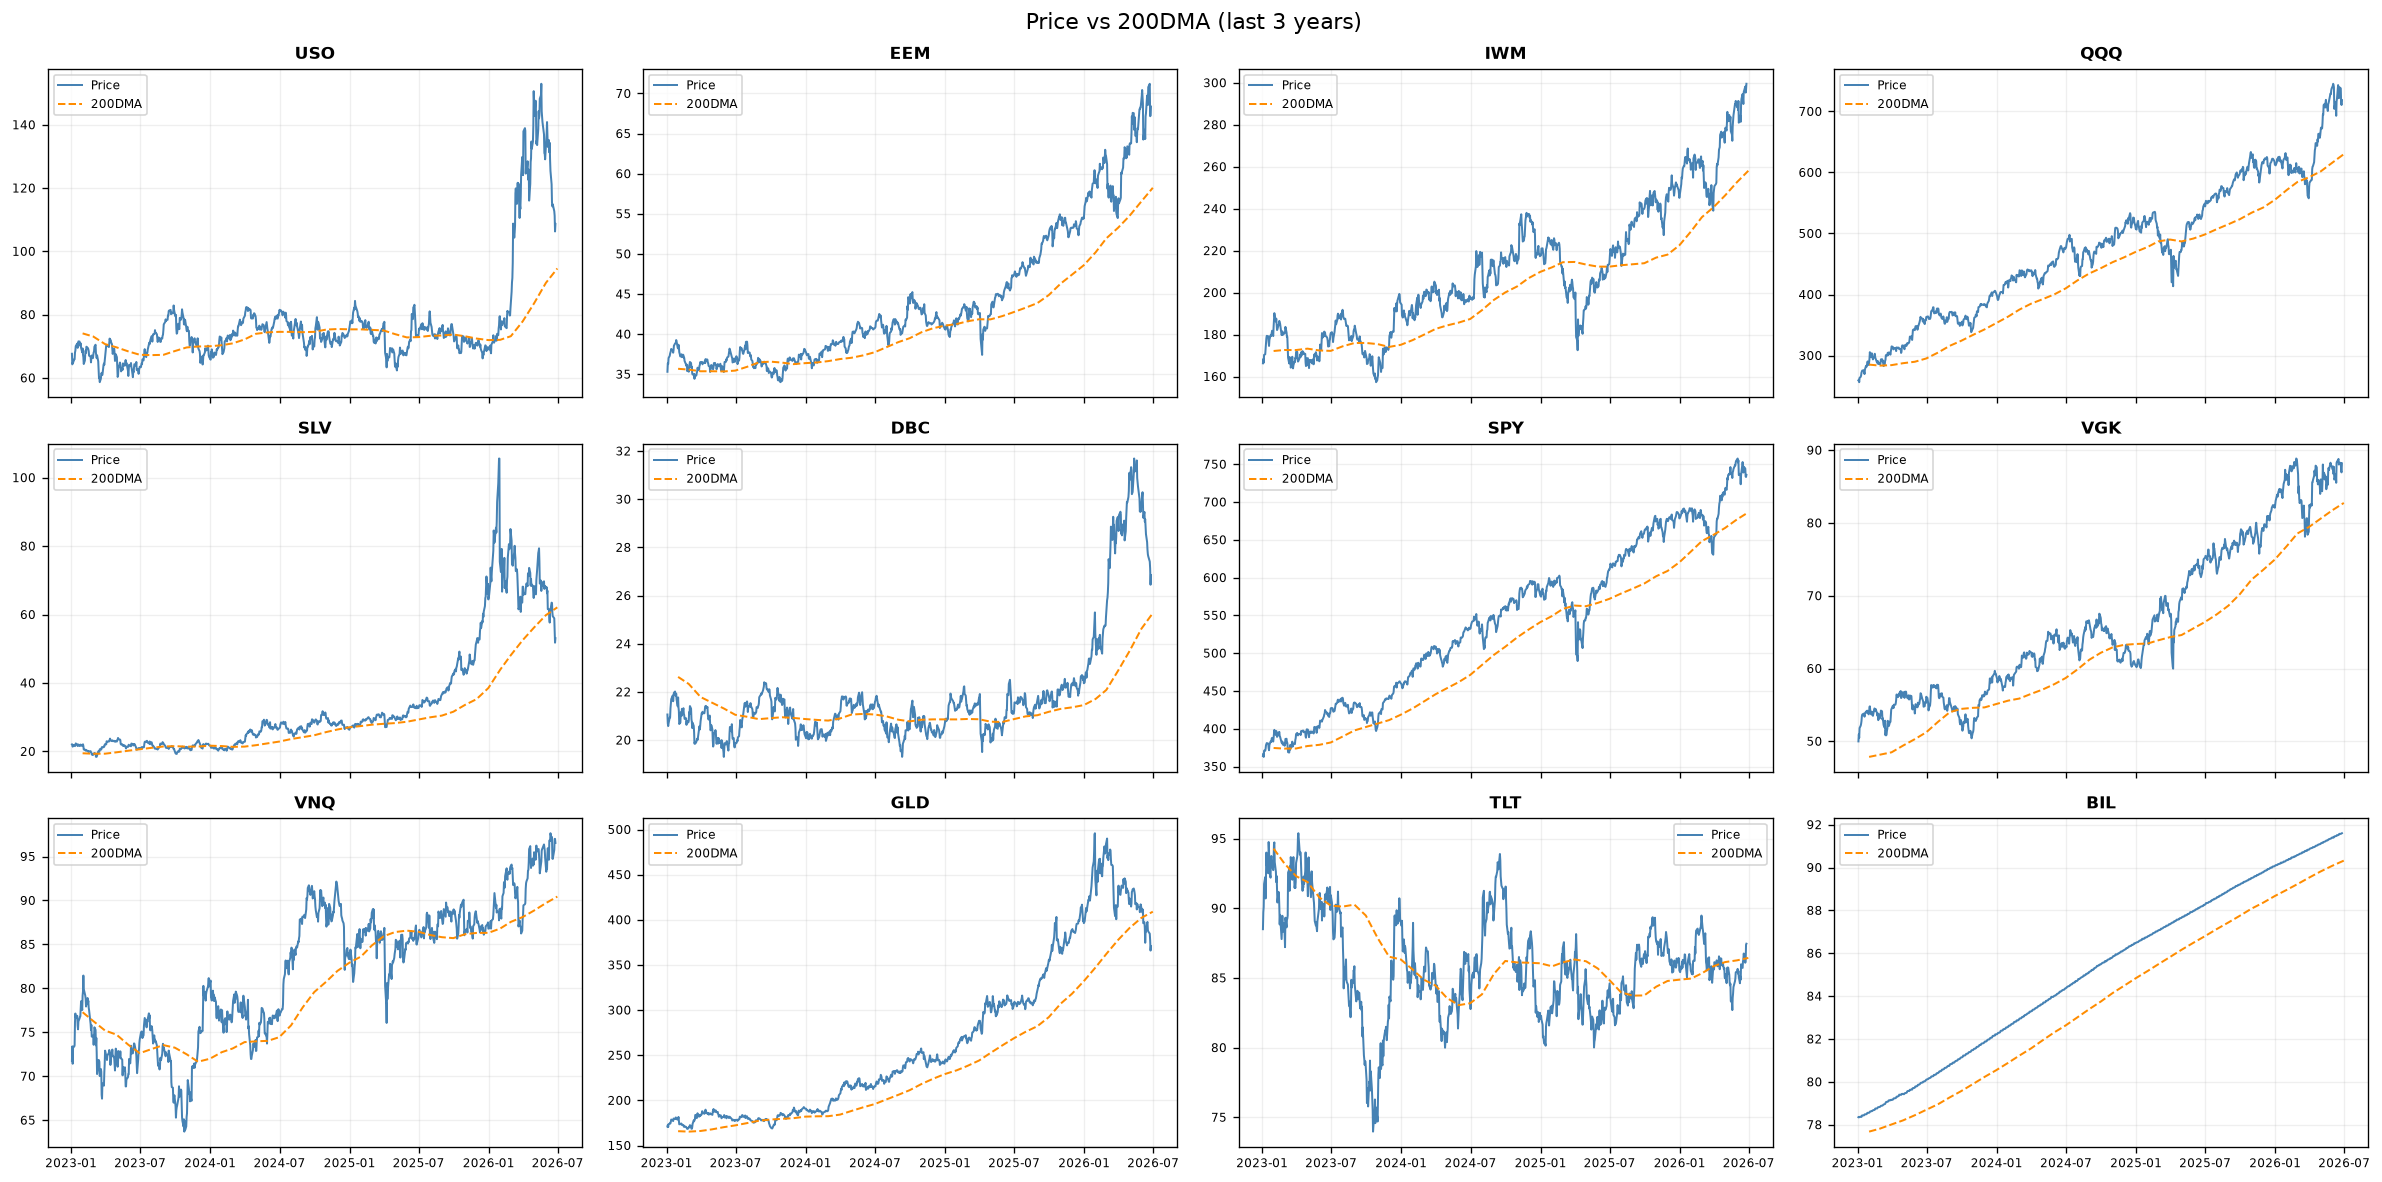

In [6]:
# Show last 3 years for readability
cutoff = pd.Timestamp('2023-01-01')
px3    = prices[prices.index >= cutoff]
dma3   = sig['dma200'][sig['dma200'].index >= cutoff]

tickers_to_plot = tickers_sorted[:12]   # top 12 by latest score
fig, axes = plt.subplots(3, 4, figsize=(20, 10), sharex=True)
axes = axes.flatten()

for ax, tkr in zip(axes, tickers_to_plot):
    ax.plot(px3.index, px3[tkr],   label='Price',   color='steelblue',  linewidth=1.2)
    ax.plot(dma3.index, dma3[tkr], label='200DMA',  color='darkorange', linewidth=1.2, linestyle='--')
    ax.set_title(tkr, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

for ax in axes[len(tickers_to_plot):]:
    ax.set_visible(False)

fig.suptitle('Price vs 200DMA (last 3 years)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Volatility — latest vs historical average

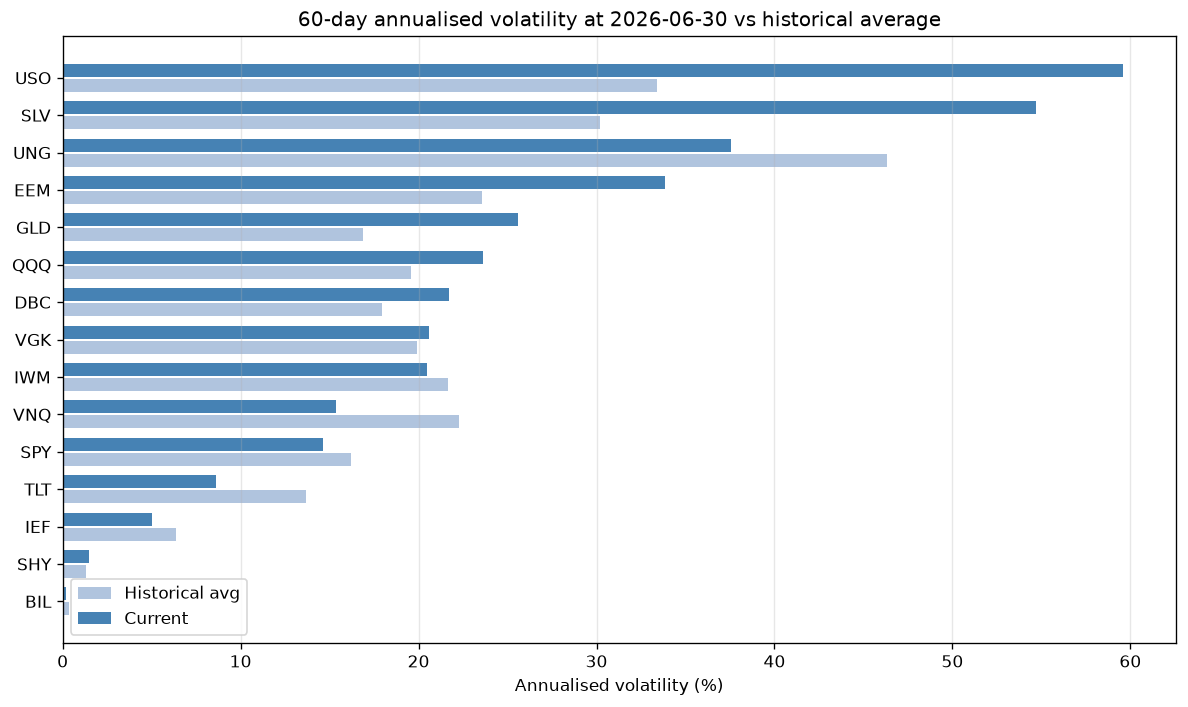

In [7]:
vol_now  = sig['vol_60d'].loc[last] * 100
vol_mean = sig['vol_60d'].mean()    * 100

ordered_by_vol = vol_now.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ordered_by_vol))
ax.barh(x - 0.2, vol_mean[ordered_by_vol.index], 0.35, label='Historical avg', color='lightsteelblue')
ax.barh(x + 0.2, ordered_by_vol.values,          0.35, label='Current',        color='steelblue')
ax.set_yticks(x)
ax.set_yticklabels(ordered_by_vol.index)
ax.set_xlabel('Annualised volatility (%)')
ax.set_title(f'60-day annualised volatility at {last.date()} vs historical average')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Score heatmap — last 24 months

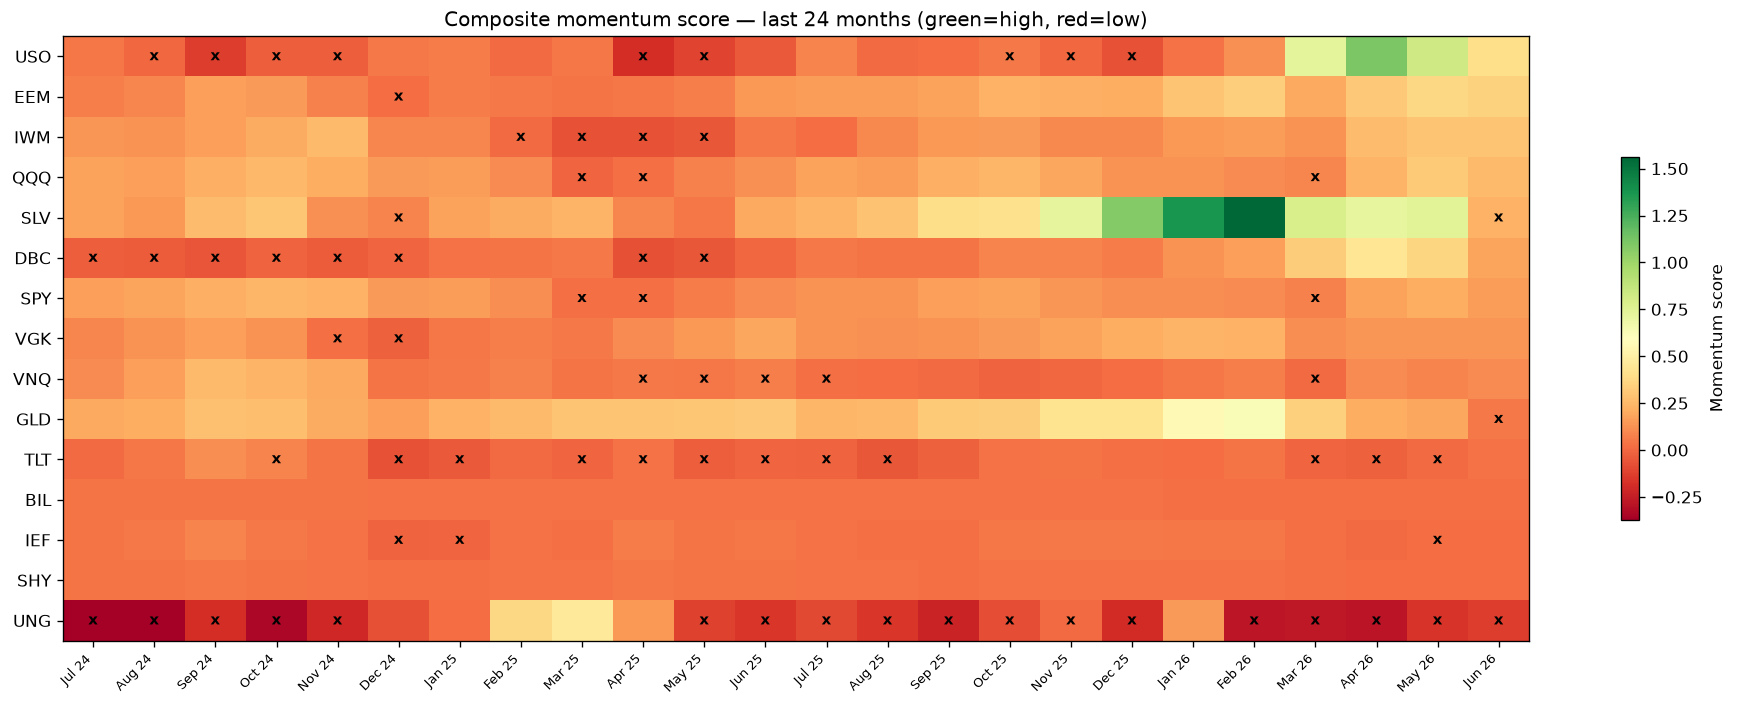

In [8]:
heat = score.tail(24)[tickers_sorted]

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heat.T.values, cmap='RdYlGn', aspect='auto',
               vmin=heat.values.min(), vmax=heat.values.max())
plt.colorbar(im, ax=ax, shrink=0.6, label='Momentum score')

ax.set_yticks(range(len(tickers_sorted)))
ax.set_yticklabels(tickers_sorted)
ax.set_xticks(range(len(heat.index)))
ax.set_xticklabels([d.strftime('%b %y') for d in heat.index], rotation=45, ha='right', fontsize=8)
ax.set_title('Composite momentum score — last 24 months (green=high, red=low)')

# overlay eligibility: mark ineligible with X
elig_heat = elig.tail(24)[tickers_sorted]
for j, tkr in enumerate(tickers_sorted):
    for i, dt in enumerate(heat.index):
        if not elig_heat.loc[dt, tkr]:
            ax.text(i, j, 'x', ha='center', va='center', fontsize=9,
                    color='black', fontweight='bold')

plt.tight_layout()
plt.show()